# Explore fine-tuning data

Loads the raw (`build_dataset.py`) and curated (`prepare_split.py`) `.jsonl` files for manual inspection: row composition, entity/typo detection, `crm_context`, `word_confidence`, and side-by-side transcript samples.

Set the paths below to whichever files you want to inspect -- defaults to the sample built alongside this notebook (`--max-calls 4000`, not the full corpus; see `README.md` for the full-corpus commands).

In [1]:
import json
import sys
from collections import Counter
from pathlib import Path

import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

RAW_PATH = REPO_ROOT / "data" / "asr_dataset_raw.jsonl"
CURATED_PATH = REPO_ROOT / "data" / "asr_dataset_curated.jsonl"

def load_rows(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f]

raw_rows = load_rows(RAW_PATH)
curated_rows = load_rows(CURATED_PATH)
print(f"raw:     {len(raw_rows):>7,} rows  ({RAW_PATH.name})")
print(f"curated: {len(curated_rows):>7,} rows  ({CURATED_PATH.name})")

raw:     164,445 rows  (asr_dataset_raw.jsonl)
curated: 183,880 rows  (asr_dataset_curated.jsonl)


## 1. Composition: raw vs. curated

`prepare_split.py` reshapes the mix a lot -- assembled (full-channel) dominance, agree-bucket upsampling, and entity upsampling all change what a random row looks like. This is the same breakdown `prepare_split.py` prints to stderr during a real run, recomputed here so you can slice it interactively.

In [2]:
def composition(rows, label):
    n = len(rows)
    n_assembled = sum(1 for r in rows if r["assembled"])
    n_chunked = n - n_assembled
    buckets = Counter(r.get("bucket") for r in rows if not r["assembled"])
    n_crm = sum(1 for r in rows if r.get("crm_context"))
    return {
        "dataset": label,
        "rows": n,
        "assembled": n_assembled,
        "assembled_frac": round(n_assembled / n, 3) if n else 0,
        "chunked": n_chunked,
        "chunked_agree_bucket": buckets.get("agree", 0),
        "rows_with_crm_context": n_crm,
    }

pd.DataFrame([composition(raw_rows, "raw"), composition(curated_rows, "curated")]).set_index("dataset")

,rows,assembled,assembled_frac,chunked,chunked_agree_bucket,rows_with_crm_context
dataset,,,,,,
raw,164445,97574,0.593,66871,7651,24369
curated,183880,166703,0.907,17177,3768,48045


## 2. Entity / typo detection, applied live

Reuses `prepare_split.py`'s actual detection functions (not a re-implementation) so what you see here matches exactly what a real curation run would upsample. `crm_entity_words`/`confidence_entity_words` need the corpus word-frequency table for the rarity gate -- built once, same as `prepare_split.py`'s own `main()` does.

In [3]:
from prepare_split import (
    crm_entity_words,
    confidence_entity_words,
    word_frequency,
    resample,
    downsample_to_ratio,
)

# Same defaults prepare_split.py's CLI uses (matches how the curated file was built,
# since it was run with no overrides) -- kept explicit here rather than re-parsing argv.
WER_CAP, OVERLAP_FLOOR = 1.0, 30.0
AGREE_TARGET_FRAC, ASSEMBLED_TARGET_FRAC = 0.225, 0.85
MIN_LEN, CONF_MAX, CONF_MAX_FREQ = 3, 0.45, 3  # prepare_split.py current defaults

# Reconstructing entity_pool from the *curated* output isn't reliable: entity
# upsampling's --entity-max-repeats cap can downsample (not just upsample) the
# original entity-row pool, so some rows that genuinely qualified never made the
# final cut -- deduping the output file underestimates the true pool prepare_split.py
# ran its rarity check against, which was too permissive here in practice (verified:
# it roughly tripled the confidence-match count vs. rebuilding from raw). Replicating
# prepare_split.py's actual pipeline stages from the *raw* file instead, up to (but not
# including) entity upsampling itself, reproduces the exact pool it used.
import random
rng = random.Random(42)  # prepare_split.py's own default --seed

wer_ok = [r for r in raw_rows if r.get("wer_whisper") is not None and r["wer_whisper"] <= WER_CAP]
kept = [r for r in wer_ok if r.get("overlap_pct") is not None and r["overlap_pct"] >= OVERLAP_FLOOR]
chunked = [r for r in kept if not r["assembled"]]
assembled = [r for r in kept if r["assembled"]]
agree = [r for r in chunked if r.get("bucket") == "agree"]
other = [r for r in chunked if r.get("bucket") != "agree"]
agree_target = round(AGREE_TARGET_FRAC / (1 - AGREE_TARGET_FRAC) * len(other))
agree_final = resample(agree, agree_target, rng) if agree else []
chunked_before_balance = other + agree_final
assembled_final, chunked_final = downsample_to_ratio(
    assembled, chunked_before_balance, ASSEMBLED_TARGET_FRAC, rng
)

entity_pool = chunked_final + assembled_final
corpus_freq = word_frequency(entity_pool)
assembled_curated = assembled_final  # the actual pre-entity-upsampling assembled pool

crm_hits, conf_hits, both_hits = [], [], []
for r in assembled_curated:
    cw = crm_entity_words(r, MIN_LEN)
    fw = confidence_entity_words(r, MIN_LEN, CONF_MAX, corpus_freq, CONF_MAX_FREQ)
    if cw and fw:
        both_hits.append((r, cw, fw))
    elif cw:
        crm_hits.append((r, cw))
    elif fw:
        conf_hits.append((r, fw))

print(f"{len(assembled_curated)} assembled rows in the pool prepare_split.py's entity step actually saw")
print(f"  CRM-only match:        {len(crm_hits)}")
print(f"  confidence-only match: {len(conf_hits)}")
print(f"  both signals matched:  {len(both_hits)}")
print(f"  neither (no entity signal): {len(assembled_curated) - len(crm_hits) - len(conf_hits) - len(both_hits)}")

97336 assembled rows in the pool prepare_split.py's entity step actually saw
  CRM-only match:        2724
  confidence-only match: 19295
  both signals matched:  554
  neither (no entity signal): 74763


In [4]:
def show_row(r, highlight_words=None, width=300):
    """Prints whisper/reference side by side, wrapping highlight_words in **stars**."""
    def mark(text):
        if not highlight_words:
            return text[:width]
        out = text
        for w in highlight_words:
            out = out.replace(w, f"**{w}**")
        return out[: width + 20 * len(highlight_words)]

    print("call_id :", r.get("call_id"), "| channel:", r.get("channel"))
    print("whisper :", mark(r["text_whisper"]))
    print("ref     :", mark(r["text"]))
    if r.get("crm_context"):
        crm = r["crm_context"]
        print("customer:", crm.get("customer", {}).get("name"), "| owner:", crm.get("crm", {}).get("owner_name"))

print("=" * 30, "CRM-confirmed entity example", "=" * 30)
if crm_hits:
    r, words = crm_hits[0]
    show_row(r, highlight_words=words)

print()
print("=" * 30, "confidence-based entity example", "=" * 30)
if conf_hits:
    r, words = conf_hits[0]
    show_row(r, highlight_words=words)
    print("confidence:", {w: r["word_confidence"].get(w) for w in words})

============================== CRM-confirmed entity example ==============================
call_id : 3e8e5b47d83d6256f515c601de27134aa45e1ebfc7fb07bbaf3fc1a05e7f4b18 | channel: 0
whisper : سلام زنده باشین یه شماره تماس جدید چند لحظه بررسی کنم سفارش رو به نام خانم **فرناز** ستود سفارش جاری با همین شماره نهصد و یک بوده یه پرده داشتین چند رنگه کاتینا کاتیا متاسفانه بنده صدای شما رو ندارم اگر صدای بنده رو دارین لطفا جابجا ببشین
ref     : می‌کنم سلام زنده باشید این شماره تماس جدید چند هفته بررسی کنم سفارش رو به نام خانم **فرناز** ستوده سفارش جاری با همین شماره نهصد و یک بوده یه پرده داشتیم چند رنگ کاتینا کاتیا متاسفانه بنده صدای شما رو ندارم اگر صدای بندر رو دارین لطفا جابه‌جا بشین
customer: فرناز طاهری | owner: محدثه آرین (فرانت)

============================== confidence-based entity example ==============================
call_id : fae741f83b38df3f5cecb689b88bbb15b95a56e99be6a0781b5892401cf0b4f1 | channel: 1
whisper : خانم علیی خانم علیی خوب هستین شما صحبتون بخیر بابت پیگیری سفارشم واقعا 

## 3. `word_confidence` -- Soniox's own per-word confidence

Only present on assembled rows. Sorted low-to-high so the least-confident words in a row surface first -- these are exactly the candidates the confidence-based entity detection draws from.

In [5]:
rows_with_conf = [r for r in assembled_curated if r.get("word_confidence")]
print(f"{len(rows_with_conf)}/{len(assembled_curated)} assembled rows have word_confidence data")

if rows_with_conf:
    r = rows_with_conf[0]
    lowest = sorted(r["word_confidence"].items(), key=lambda kv: kv[1])[:15]
    print("\nlowest-confidence words in one sample row:")
    for w, c in lowest:
        print(f"  {w!r:<20} {c:.3f}")

97240/97336 assembled rows have word_confidence data

lowest-confidence words in one sample row:
  'حیدرزاده'           0.510
  'سفارش\u200cتون'     0.531
  'راهنماییتون'        0.621
  'می\u200cپذیرن'      0.642
  'بله'                0.651
  'شما'                0.672
  'خدانگهدار'          0.674
  'می\u200cکنم'        0.679
  'هستم'               0.695
  'به'                 0.723
  'حیدری\u200cزاده'    0.764
  'باشین'              0.777
  'کالا'               0.777
  'کاویان'             0.782


## 4. Metric distributions

`wer_whisper`/`word_diff_pct`/`overlap_pct` are computed once in `build_dataset.py` and carried through curation -- these are the same numbers `prepare_split.py`'s `--wer-cap`/`--overlap-floor` filter against.

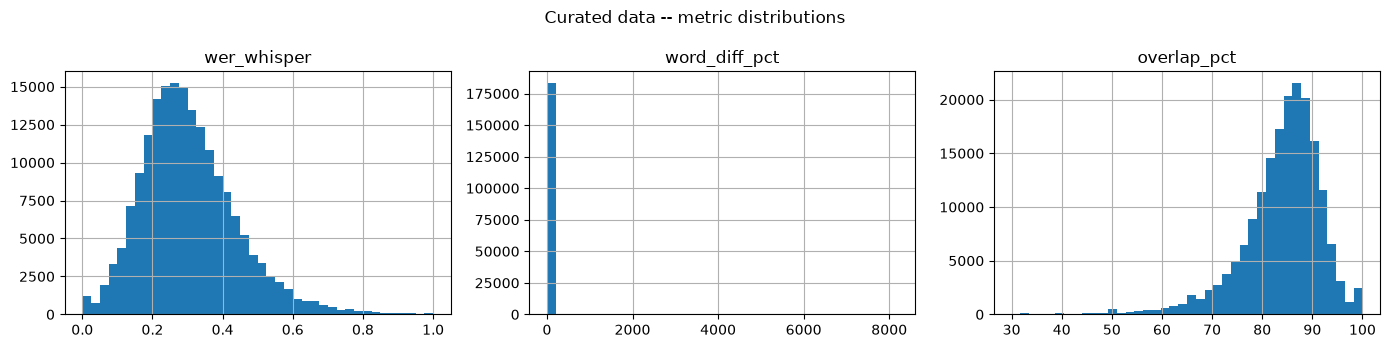

,wer_whisper,word_diff_pct,overlap_pct
count,183880.000000,183880.000000,183880.000000
mean,0.304095,10.366122,83.902581
std,0.136221,43.405666,8.047822
min,0.000000,0.000000,30.000000
25%,0.210900,2.320000,80.310000
50%,0.287200,5.000000,85.250000
75%,0.379400,10.000000,89.040000
max,1.000000,8200.000000,100.000000


In [6]:
import matplotlib.pyplot as plt

df = pd.DataFrame(curated_rows)
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, ["wer_whisper", "word_diff_pct", "overlap_pct"]):
    df[col].dropna().hist(bins=40, ax=ax)
    ax.set_title(col)
fig.suptitle("Curated data -- metric distributions")
fig.tight_layout()
plt.show()

df[["wer_whisper", "word_diff_pct", "overlap_pct"]].describe()

## 5. Input/output length distributions

Word counts for `text_whisper` (input) and `text`/target (output), split by assembled vs. chunked -- the two are on very different scales (a full channel vs. one segment), so plotting them together would just show chunked as a spike near zero next to the assembled distribution.

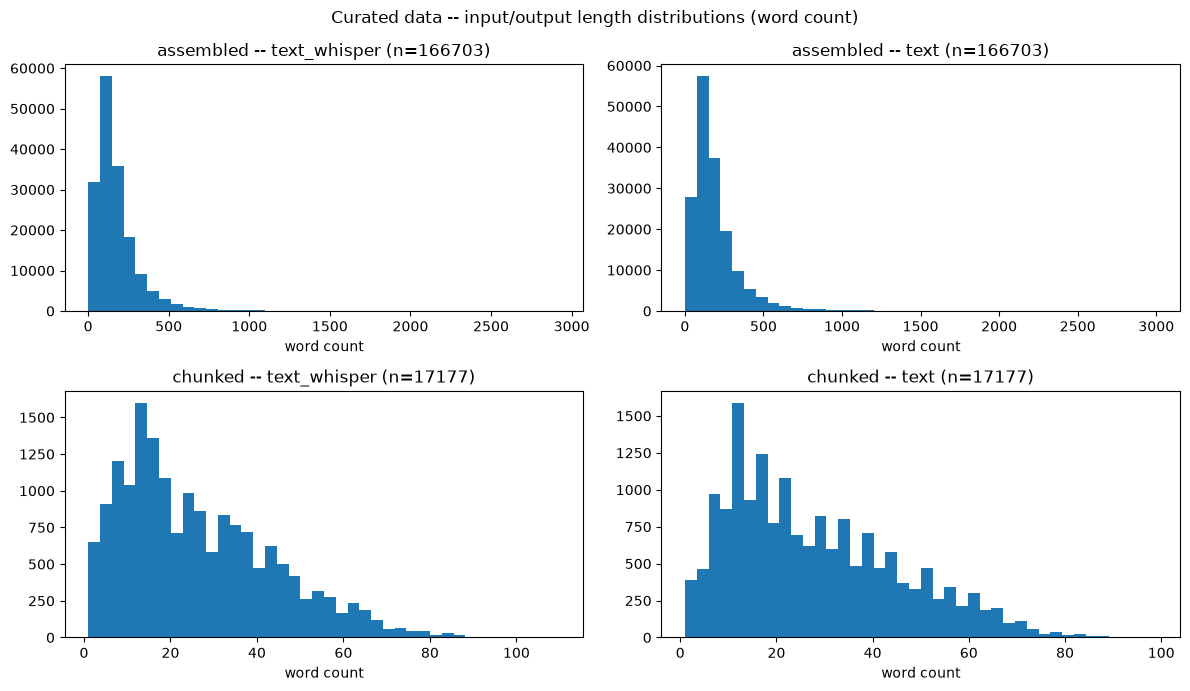

,assembled_text_whisper,assembled_text,chunked_text_whisper,chunked_text
count,166703.00000,166703.000000,17177.000000,17177.000000
mean,176.79019,189.217675,26.347034,27.976888
std,153.38709,162.793953,17.450192,17.618727
min,1.00000,1.000000,1.000000,1.000000
25%,86.00000,93.000000,12.000000,14.000000
50%,138.00000,148.000000,23.000000,24.000000
75%,218.00000,233.000000,38.000000,40.000000
max,2926.00000,3001.000000,110.000000,99.000000


In [7]:
def word_lengths(rows, col):
    return [len(r[col].split()) for r in rows]

length_groups = [
    ("assembled", [r for r in curated_rows if r["assembled"]]),
    ("chunked", [r for r in curated_rows if not r["assembled"]]),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for row_idx, (label, subset) in enumerate(length_groups):
    for col_idx, col in enumerate(["text_whisper", "text"]):
        ax = axes[row_idx, col_idx]
        lengths = word_lengths(subset, col)
        ax.hist(lengths, bins=40)
        ax.set_title(f"{label} -- {col} (n={len(subset)})")
        ax.set_xlabel("word count")
fig.suptitle("Curated data -- input/output length distributions (word count)")
fig.tight_layout()
plt.show()

pd.DataFrame({
    f"{label}_{col}": pd.Series(word_lengths(subset, col))
    for label, subset in length_groups
    for col in ["text_whisper", "text"]
}).describe()

## 6. Low-signal correction masking

Reuses `data.py`'s actual `low_signal_word_spans()` (not a re-implementation), gated on phonetic similarity (Persian-homophone-normalized) and corpus rarity -- see `Config.mask_low_signal_corrections` and README's "Low-signal correction masking". This is the exact function `build_example()` calls during tokenization when that flag is on; what you see here (spans, counts) is what would actually get masked out of the loss (labels = -100), not an approximation of it.

In [8]:
from data import low_signal_word_spans

MASK_MIN_SIMILARITY, MASK_MAX_COMMON_FREQ = 0.75, 1  # train.py Config defaults

masked_examples = 0
masked_word_counts = Counter()
example_rows = []
for r in curated_rows:
    spans = low_signal_word_spans(
        r["text_whisper"], r["text"], MASK_MIN_SIMILARITY, corpus_freq, MASK_MAX_COMMON_FREQ
    )
    if not spans:
        continue
    masked_examples += 1
    masked_words = [r["text"][s:e] for s, e in spans]
    masked_word_counts.update(masked_words)
    if len(example_rows) < 5:
        example_rows.append((r, masked_words))

print(f"{masked_examples}/{len(curated_rows)} curated rows ({100*masked_examples/len(curated_rows):.1f}%) "
      f"would have at least one span masked out of the loss")
print(f"{sum(masked_word_counts.values())} total masked word-spans, "
      f"{len(masked_word_counts)} distinct")
print("\nmost commonly masked spans:")
for w, c in masked_word_counts.most_common(20):
    print(f"  {c:4d}  {w!r}")

print("\n" + "=" * 30, "example masked rows", "=" * 30)
for r, masked_words in example_rows:
    show_row(r, highlight_words=masked_words)
    print("masked:", masked_words)
    print("-" * 100)

/Users/pedram/Desktop/LLM Fine-tuning/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


65824/183880 curated rows (35.8%) would have at least one span masked out of the loss
88943 total masked word-spans, 30028 distinct

most commonly masked spans:
     5  'بزنیدا'
     5  'نیم\u200cساعته\u200cست و'
     5  'سوزن\u200cنخی'
     5  'موندنی'
     5  'بزرگ\u200cبه\u200cانش'
     5  'خال\u200cخالی'
     5  'خواهشمم اینه که'
     5  'رازه'
     5  'صدام چهارمخ نمیتونم'
     5  'کماشهر'
     5  'متفرستم'
     5  'دردنخوری'
     5  'یعنی الان فقط سر گرونی\u200cست چون یه تعداد'
     5  'شایعه\u200cای'
     5  'مهجورش'
     5  'فرستاد نمیشین من'
     5  'ضریف'
     5  'حالا این معمولی\u200cاش هرکسه'
     5  'کسری\u200cدستور'
     5  'جاروشاری بوشت'

============================== example masked rows ==============================
call_id : 0e4ad406f9b08e2c38277d0c1719c58eae41b659a82f38bb8ffd4cc0d55bd673 | channel: 1
whisper : الو سلام وقتتون بخیر آقا من یه سفارش داشتم به گوشی خانمم یه گوشی آبیسته شش سفارش داده بودم امروز باید به دست من میرسیده خب الان اومدم تو گنجینه دیگه هم نیومد

## 7. Random sample browser

Re-run this cell for a fresh random sample (no fixed seed -- this is for manual eyeballing, not a reproducible metric).

In [9]:
import random

N_SAMPLES = 5
for r in random.sample(curated_rows, min(N_SAMPLES, len(curated_rows))):
    show_row(r)
    print(f"assembled={r['assembled']} wer_whisper={r.get('wer_whisper')} bucket={r.get('bucket')}")
    print("-" * 100)

call_id : 6609ceb30b8dae0e5a9188653a948174ac1094b33680dea2d7909adcb344c4b4 | channel: 0
whisper : سلام بفرمایید متشکرم بفرمایید سه بله اجازه بدید من چک کنم موردتون رو سفارش به نام خانم حسابی درسته وقت چوب و چند قلم کل بله از سه شهریور تا الان متاسفانه خیلی بازه زمانی طولانی هست کاملا حق میدن خانم حسابی بابت این مورد رو نورزی باشید من هم اگر جای شما بودم نورزه اعتبار بنده هم پیش میادقرار بودش که 
ref     : هستم بفرمایید متشکرم بفرمایید درسته بله اجازه بدید من چک کنم موردتون رو سفارش بنو می‌خوام حسابی درسته تخته‌چوب و چند قلم کالبند از سه شهریور تا الان متاسفانه خیلی بازه زمانی طولانی هست کاملا حق می‌دونم می‌خوام حسابی بابت این مورد ناراضی باشید من هم اگر جای شما بودم نارضایتی برای بنده هم پیش می‌آمد ق
assembled=True wer_whisper=0.2705 bucket=None
----------------------------------------------------------------------------------------------------
call_id : 6f51525ca8499c23826b5e3334ef12d0ac08a34272ebe10ee8f318b907e20019 | channel: 1
whisper : خانم وقتتون بخیر خسته نکنم من صبح هم با شما ص

## 8. Look up a specific call

Handy after spotting something interesting in section 5 -- pulls every row (both raw and curated, both channels if assembled) for one `call_id`, plus the full per-turn breakdown for assembled rows.

In [10]:
CALL_ID = curated_rows[0]["call_id"]  # replace with any call_id you want to inspect

print(f"=== call_id: {CALL_ID} ===\n")
for label, rows in [("raw", raw_rows), ("curated", curated_rows)]:
    matches = [r for r in rows if r["call_id"] == CALL_ID]
    print(f"--- {label}: {len(matches)} row(s) ---")
    for r in matches:
        show_row(r)
        if r.get("turns"):
            print(f"  ({len(r['turns'])} turns)")
        print()

=== call_id: 0e4ad406f9b08e2c38277d0c1719c58eae41b659a82f38bb8ffd4cc0d55bd673 ===

--- raw: 2 row(s) ---
call_id : 0e4ad406f9b08e2c38277d0c1719c58eae41b659a82f38bb8ffd4cc0d55bd673 | channel: 0
whisper : می‌تونم کمکتون کنم سلام قربان وقتتون بخیر باشه بله خواهش می‌کنم شماره سفارشتون رو می‌فرمایید قربان صفر نهصد و بیست و دو بله بله بدید من اینو مجدد از اینجای دیگه چک کنم عذر می‌خوام بابت این مسیلهقرار بوده سفارش امروز به دستتون برسه اما نرسیده درسته بعد بابت این مسیله براتون پیامک اومد که به این آدرس 
ref     : چطور می‌تونم کمکتون کنم سلام قربان وقتتون بخیر باشه بله خواهش می‌کنم شماره سفارشتون رو می‌فرمایید قربان صفر نه دو دو بله شما اجازه بدید من اینو مجدد از یه جای دیگه چک کنم عذر می‌خوام بابت این مسیله قرار بوده سفارش امروز به دستتون برسه اما نرسیده درست بعد بابت این مسیله براتون پیامک اومد که به این آد
  (16 turns)

call_id : 0e4ad406f9b08e2c38277d0c1719c58eae41b659a82f38bb8ffd4cc0d55bd673 | channel: 1
whisper : الو سلام وقتتون بخیر آقا من یه سفارش داشتم به گوشی خانمم یه گوشی آبیسته ش

--- curated: 5 row(s) ---
call_id : 0e4ad406f9b08e2c38277d0c1719c58eae41b659a82f38bb8ffd4cc0d55bd673 | channel: 1
whisper : الو سلام وقتتون بخیر آقا من یه سفارش داشتم به گوشی خانمم یه گوشی آبیسته شش سفارش داده بودم امروز باید به دست من میرسیده خب الان اومدم تو گنجینه دیگه هم نیومده در ما خب بعد میخواستم ببینم این بزرگ چجوریه چون من فردا شدم مسافرم الان فروشنده همین جایی که هستم دیگه دیجی کالا مامولا اینجوری که گرون میشه 
ref     : الو سلام وقتتون بخیر آقا من یه سفارش داشتم با گوشی خانمم یه گوشی ای بیست و شش سفارش داده بودم امروز باید به دست من می‌رسیده خب الان اومدم تو گنجینه می‌گن نیومده برای ما بعد می‌خواستم ببینم این وضعیت چجوریه چون من فردا شب هم مسافرم الان فروشنده همین جایی که هستم می‌گه دیجی‌کالا معمولا اینجوری که گرون
  (13 turns)

call_id : 0e4ad406f9b08e2c38277d0c1719c58eae41b659a82f38bb8ffd4cc0d55bd673 | channel: 1
whisper : الو سلام وقتتون بخیر آقا من یه سفارش داشتم به گوشی خانمم یه گوشی آبیسته شش سفارش داده بودم امروز باید به دست من میرسیده خب الان اومدم تو گنجینه دیگه هم 

## 9. Search for a word across the corpus

Useful for spot-checking a specific name/term you're curious about -- e.g. one flagged by the confidence-based entity detection in section 2.

In [11]:
SEARCH_WORD = "\u062d\u06cc\u062f\u0631\u06cc"  # حیدری ("Heydari") -- replace with any word

matches = [r for r in curated_rows if SEARCH_WORD in r["text"].split() or SEARCH_WORD in r["text_whisper"].split()]
print(f"{len(matches)} curated rows mention {SEARCH_WORD!r}\n")
for r in matches[:5]:
    show_row(r, highlight_words=[SEARCH_WORD])
    print()

505 curated rows mention 'حیدری'

call_id : 2f85ffd528f0e0be14a55826a502517b66420b40d848c685bf436d048e308cbb | channel: 1
whisper : سلام سرکار خانم خوب هستید ببخشید من الان یه دقیقه که بود دوازده دقیقه مطلع شدم خودم مخابر دستم واقعا نرم افزاری میتونم بذارم که زمان سیزده راحت تشخیص بده مثل اوکالا یه موانع انتقاد من جسارتا دختر خانمم یه دونه قرص بهتند ویت گرفته پنج شهریور قرار رو بیاد منزل موندیم بعد گفتن شنبه شنبه هم نیاوردن بعد گفتن دوشنبه دوشنبه ه
ref     : سلام سرکار خانم خوب هستید ببخشید من الان نصفش یه دقیقه که بود دوازده دقیقه معطل شدم چون خودم مخابراتی هستم لااقل نرم‌افزاری می‌تونم بذارم که زمان رسید رو راحت تشخیص بده مثل اوکالا این هم به‌عنوان انتقاد من جسارتا دختر خانمم یه دونه قرص بتان ویت گرفته پنج شهریور قرار بود بیاد منزل موندیم بعد گفتن شنبه شنبه هم نیاوردن بع

call_id : 2a52c77637fa155727d25baeab4b996dfce27d9551c23456a67f2b97e62ecb2f | channel: 1
whisper : الو خانم قربان من دو تا بار قبلی توی بارم ناقص دو تا چاقوی هیدری نبوده خب چندین بار هم من پیگیری کردم حتی به مامور هم